# 🛡️ IoT Intrusion Detection System — Full ML Pipeline
**Team:** Jinhong Lin · Elton Chang · Shiwei Jiang  
**Dataset:** BoTNeTIoT-L01 (Kaggle)  
**Goal:** Detect and classify IoT botnet traffic using ML models (LR, RF, HGB, MLP)

---
| Section | Description |
|---------|-------------|
| 0 | Setup, Installs, Unzip Data |
| 1 | Data Loading (stratified chunked) |
| 2 | Exploratory Data Analysis |
| 3 | Preprocessing Pipeline |
| 4 | Binary Classification (Attack vs Normal) |
| 5 | Multiclass (Attack Family & Subtypes) |
| 6 | Feature Importance |
| 7 | Per-Device Evaluation |
| 8 | Latency vs Accuracy |
| 9 | Results Summary |


## Section 0 — Setup & Data Preparation

In [10]:
# Install any missing packages
!pip install -q scikit-learn pandas numpy matplotlib seaborn tqdm
print("✅ Packages ready")


✅ Packages ready


In [11]:
import os, glob, zipfile, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams.update({"figure.dpi": 110,
                     "axes.spines.top": False,
                     "axes.spines.right": False})
print("✅ Imports complete")


✅ Imports complete


In [12]:
# ─── Auto-unzip any .zip files in /content/ ──────────────────────────────────
CONTENT = Path("/content")

for zf in CONTENT.glob("*.zip"):
    csv_name = zf.stem + ".csv"
    if not (CONTENT / csv_name).exists():
        print(f"Unzipping {zf.name} …")
        with zipfile.ZipFile(zf) as z:
            z.extractall(CONTENT)
        print(f"  → extracted")
    else:
        print(f"  ✓ {csv_name} already exists, skipping")

# ─── Locate CSV files ─────────────────────────────────────────────────────────
def find_csv(keyword):
    """Find a CSV in /content/ whose name contains keyword (case-insensitive)."""
    hits = list(CONTENT.glob("*.csv"))
    hits = [p for p in hits if keyword.lower() in p.name.lower()]
    if not hits:
        raise FileNotFoundError(
            f"No CSV containing '{keyword}' found in /content/.\n"
            f"Files present: {[p.name for p in CONTENT.glob('*') if not p.is_dir()]}"
        )
    return str(sorted(hits)[0])   # pick first match if multiple

CSV1_PATH = find_csv("NoDuplicate")   # BotNeTIoT-L01_label_NoDuplicates.csv
CSV2_PATH = find_csv("v2")             # BoTNeTIoT-L01-v2.csv

print(f"\nDataset 1: {CSV1_PATH}")
print(f"Dataset 2: {CSV2_PATH}")


  ✓ BoTNeTIoT-L01-v2.csv already exists, skipping
  ✓ BotNeTIoT-L01_label_NoDuplicates.csv already exists, skipping

Dataset 1: /content/BotNeTIoT-L01_label_NoDuplicates.csv
Dataset 2: /content/BoTNeTIoT-L01-v2.csv


In [13]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────────
# How many rows to load (use None for the full dataset — slower & more RAM)
SAMPLE_N    = 300_000   # rows from Dataset 1
SAMPLE_N2   = 400_000   # rows from Dataset 2

RANDOM_STATE = 42
TEST_SIZE    = 0.15
VAL_FRAC     = 0.15 / (1 - 0.15)   # ~17.6% of train set → gives 15% of total

print(f"Sample sizes → D1: {SAMPLE_N:,}  |  D2: {SAMPLE_N2:,}")
print(f"Split: 70% train / 15% val / 15% test  (stratified)")


Sample sizes → D1: 300,000  |  D2: 400,000
Split: 70% train / 15% val / 15% test  (stratified)


## Section 1 — Data Loading

In [5]:
def stratified_sample_csv(path, n_samples, label_col='label',
                           chunksize=150_000, random_state=42):
    """
    Stream a large CSV and return a stratified subsample of n_samples rows.
    If n_samples is None, loads the entire file.
    """
    path = Path(path)
    size_mb = path.stat().st_size / 1e6
    print(f"  📂 {path.name}  ({size_mb:.0f} MB)")

    if n_samples is None:
        print("  Loading full file …")
        df = pd.read_csv(path)
        print(f"  ✅ {len(df):,} rows loaded")
        return df

    # Pass 1: collect labels only (fast)
    print(f"  Scanning labels …")
    all_labels = pd.concat(
        [chunk[label_col] for chunk in pd.read_csv(path, usecols=[label_col],
                                                    chunksize=chunksize)],
        ignore_index=True
    ).values

    # Stratified index selection
    classes, counts = np.unique(all_labels, return_counts=True)
    fracs   = counts / counts.sum()
    rng     = np.random.RandomState(random_state)
    chosen  = set()
    for c, f in zip(classes, fracs):
        idx_c  = np.where(all_labels == c)[0]
        n_c    = min(int(n_samples * f), len(idx_c))
        chosen.update(rng.choice(idx_c, size=n_c, replace=False).tolist())

    # Pass 2: read only chosen rows
    print(f"  Reading {len(chosen):,} selected rows …")
    chunks_out, row_ptr = [], 0
    for chunk in pd.read_csv(path, chunksize=chunksize):
        mask = np.array([(row_ptr + i) in chosen for i in range(len(chunk))])
        if mask.any():
            chunks_out.append(chunk[mask])
        row_ptr += len(chunk)

    df = pd.concat(chunks_out, ignore_index=True)
    print(f"  ✅ {len(df):,} rows  |  classes: { {int(c): int(n) for c,n in zip(*np.unique(df[label_col], return_counts=True))} }")
    return df


print("Loading Dataset 1 …")
df1 = stratified_sample_csv(CSV1_PATH, SAMPLE_N)

print("\nLoading Dataset 2 …")
df2 = stratified_sample_csv(CSV2_PATH, SAMPLE_N2)

# Drop unnecessary index column
for _df in [df1, df2]:
    if 'Unnamed: 0' in _df.columns:
        _df.drop(columns=['Unnamed: 0'], inplace=True)

print("\n✅ Both datasets ready")
print(f"   df1: {df1.shape}  columns: {df1.columns.tolist()}")
print(f"   df2: {df2.shape}  columns: {df2.columns.tolist()}")


Loading Dataset 1 …
  📂 BotNeTIoT-L01_label_NoDuplicates.csv  (636 MB)
  Scanning labels …
  Reading 299,999 selected rows …
  ✅ 299,999 rows  |  classes: {0: 236515, 1: 63484}

Loading Dataset 2 …
  📂 BoTNeTIoT-L01-v2.csv  (1678 MB)
  Scanning labels …
  Reading 399,999 selected rows …
  ✅ 399,999 rows  |  classes: {0: 368514, 1: 31485}

✅ Both datasets ready
   df1: (299999, 24)  columns: ['MI_dir_L0.1_weight', 'MI_dir_L0.1_mean', 'MI_dir_L0.1_variance', 'H_L0.1_weight', 'H_L0.1_mean', 'H_L0.1_variance', 'HH_L0.1_weight', 'HH_L0.1_mean', 'HH_L0.1_std', 'HH_L0.1_magnitude', 'HH_L0.1_radius', 'HH_L0.1_covariance', 'HH_L0.1_pcc', 'HH_jit_L0.1_weight', 'HH_jit_L0.1_mean', 'HH_jit_L0.1_variance', 'HpHp_L0.1_weight', 'HpHp_L0.1_mean', 'HpHp_L0.1_std', 'HpHp_L0.1_magnitude', 'HpHp_L0.1_radius', 'HpHp_L0.1_covariance', 'HpHp_L0.1_pcc', 'label']
   df2: (399999, 27)  columns: ['MI_dir_L0.1_weight', 'MI_dir_L0.1_mean', 'MI_dir_L0.1_variance', 'H_L0.1_weight', 'H_L0.1_mean', 'H_L0.1_variance', 

In [6]:
# ─── Feature columns ──────────────────────────────────────────────────────────
FEATURE_COLS = [
    'MI_dir_L0.1_weight', 'MI_dir_L0.1_mean',  'MI_dir_L0.1_variance',
    'H_L0.1_weight',      'H_L0.1_mean',        'H_L0.1_variance',
    'HH_L0.1_weight',     'HH_L0.1_mean',       'HH_L0.1_std',
    'HH_L0.1_magnitude',  'HH_L0.1_radius',     'HH_L0.1_covariance', 'HH_L0.1_pcc',
    'HH_jit_L0.1_weight', 'HH_jit_L0.1_mean',  'HH_jit_L0.1_variance',
    'HpHp_L0.1_weight',   'HpHp_L0.1_mean',    'HpHp_L0.1_std',
    'HpHp_L0.1_magnitude','HpHp_L0.1_radius',  'HpHp_L0.1_covariance','HpHp_L0.1_pcc',
]

# Confirm all features exist in df1
missing = [f for f in FEATURE_COLS if f not in df1.columns]
if missing:
    print("⚠️  Missing features:", missing)
else:
    print(f"✅ All {len(FEATURE_COLS)} features present in df1")


✅ All 23 features present in df1


## Section 2 — Exploratory Data Analysis

In [7]:
print("=" * 55)
print("DATASET 1 — Basic Info")
print("=" * 55)
print(f"  Shape  : {df1.shape}")
print(f"  Memory : {df1.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"  Missing: {df1.isnull().sum().sum()}")
print("\nLabel distribution:")
print(df1['label'].value_counts().rename({0:'Attack(0)', 1:'Normal(1)'}))


DATASET 1 — Basic Info
  Shape  : (299999, 24)
  Memory : 57.6 MB
  Missing: 0

Label distribution:
label
Attack(0)    236515
Normal(1)     63484
Name: count, dtype: int64


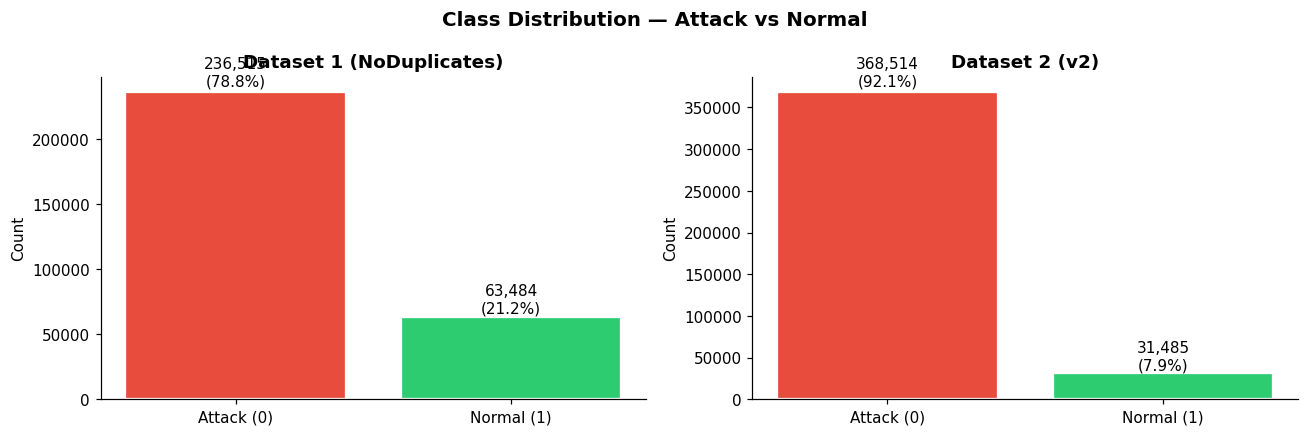

In [8]:
# ─── 2.1 Class Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df, title) in zip(axes,
        [(df1, 'Dataset 1 (NoDuplicates)'), (df2, 'Dataset 2 (v2)')]):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(['Attack (0)', 'Normal (1)'], counts.values,
                  color=['#E74C3C', '#2ECC71'], edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{v:,}\n({v/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10)

plt.suptitle('Class Distribution — Attack vs Normal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


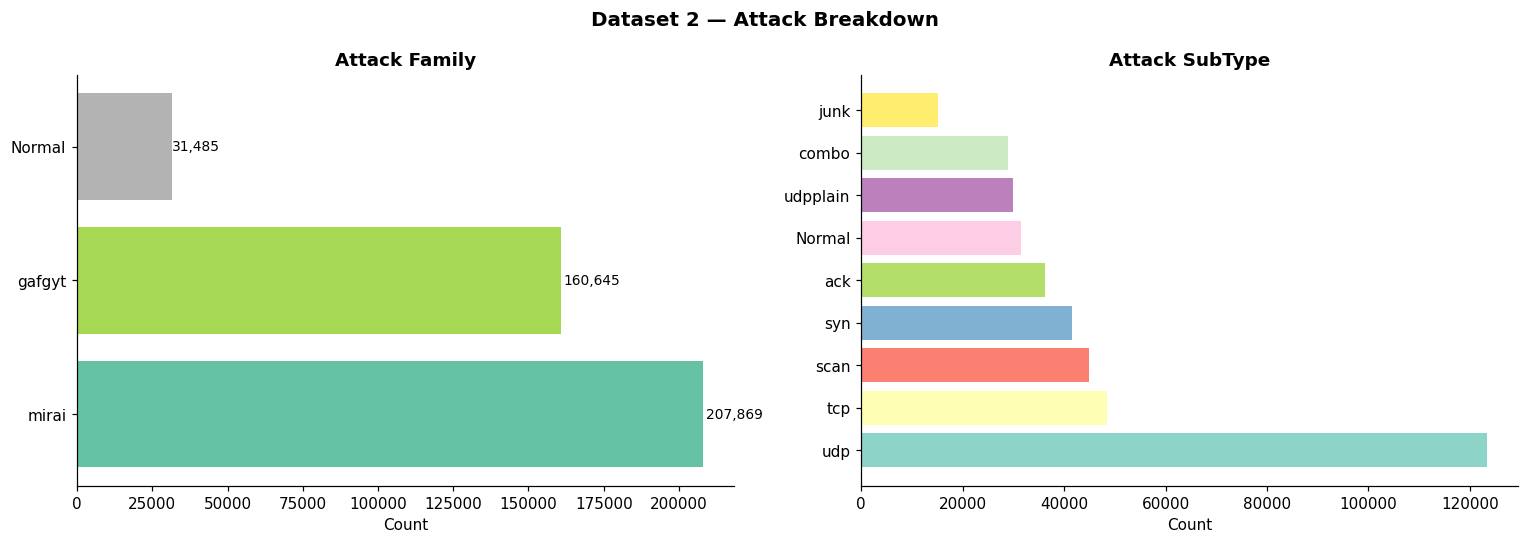

In [9]:
# ─── 2.2 Attack Type & Subtype (Dataset 2) ───────────────────────────────────
if 'Attack' in df2.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fam = df2['Attack'].value_counts()
    axes[0].barh(fam.index, fam.values,
                 color=plt.cm.Set2(np.linspace(0, 1, len(fam))))
    axes[0].set_title('Attack Family', fontweight='bold')
    axes[0].set_xlabel('Count')
    for i, v in enumerate(fam.values):
        axes[0].text(v * 1.005, i, f'{v:,}', va='center', fontsize=9)

    if 'Attack_subType' in df2.columns:
        sub = df2['Attack_subType'].value_counts()
        axes[1].barh(sub.index, sub.values,
                     color=plt.cm.Set3(np.linspace(0, 1, len(sub))))
        axes[1].set_title('Attack SubType', fontweight='bold')
        axes[1].set_xlabel('Count')

    plt.suptitle('Dataset 2 — Attack Breakdown', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('attack_distribution.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print("'Attack' column not found in df2 — skipping")


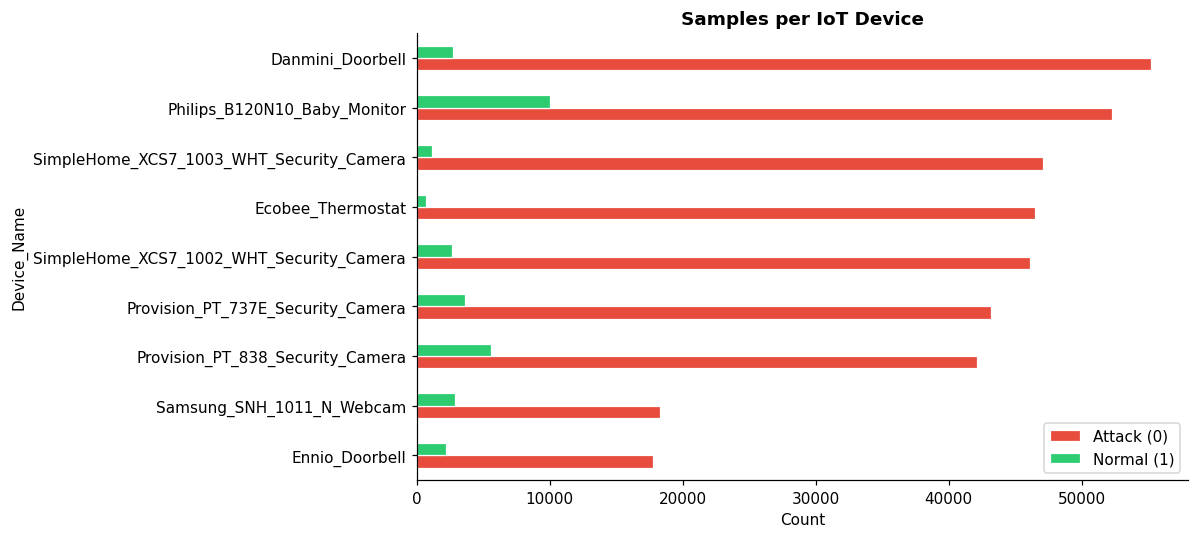

In [14]:
# ─── 2.3 Device Distribution (Dataset 2) ────────────────────────────────────
if 'Device_Name' in df2.columns:
    dev = df2.groupby('Device_Name')['label'].value_counts().unstack(fill_value=0)
    dev.columns = ['Attack', 'Normal']
    dev = dev.sort_values('Attack', ascending=True)

    fig, ax = plt.subplots(figsize=(11, 5))
    dev.plot(kind='barh', ax=ax, color=['#E74C3C', '#2ECC71'],
             edgecolor='white', linewidth=0.8)
    ax.set_title('Samples per IoT Device', fontsize=12, fontweight='bold')
    ax.set_xlabel('Count')
    ax.legend(['Attack (0)', 'Normal (1)'])
    plt.tight_layout()
    plt.savefig('device_distribution.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print("'Device_Name' not found in df2")


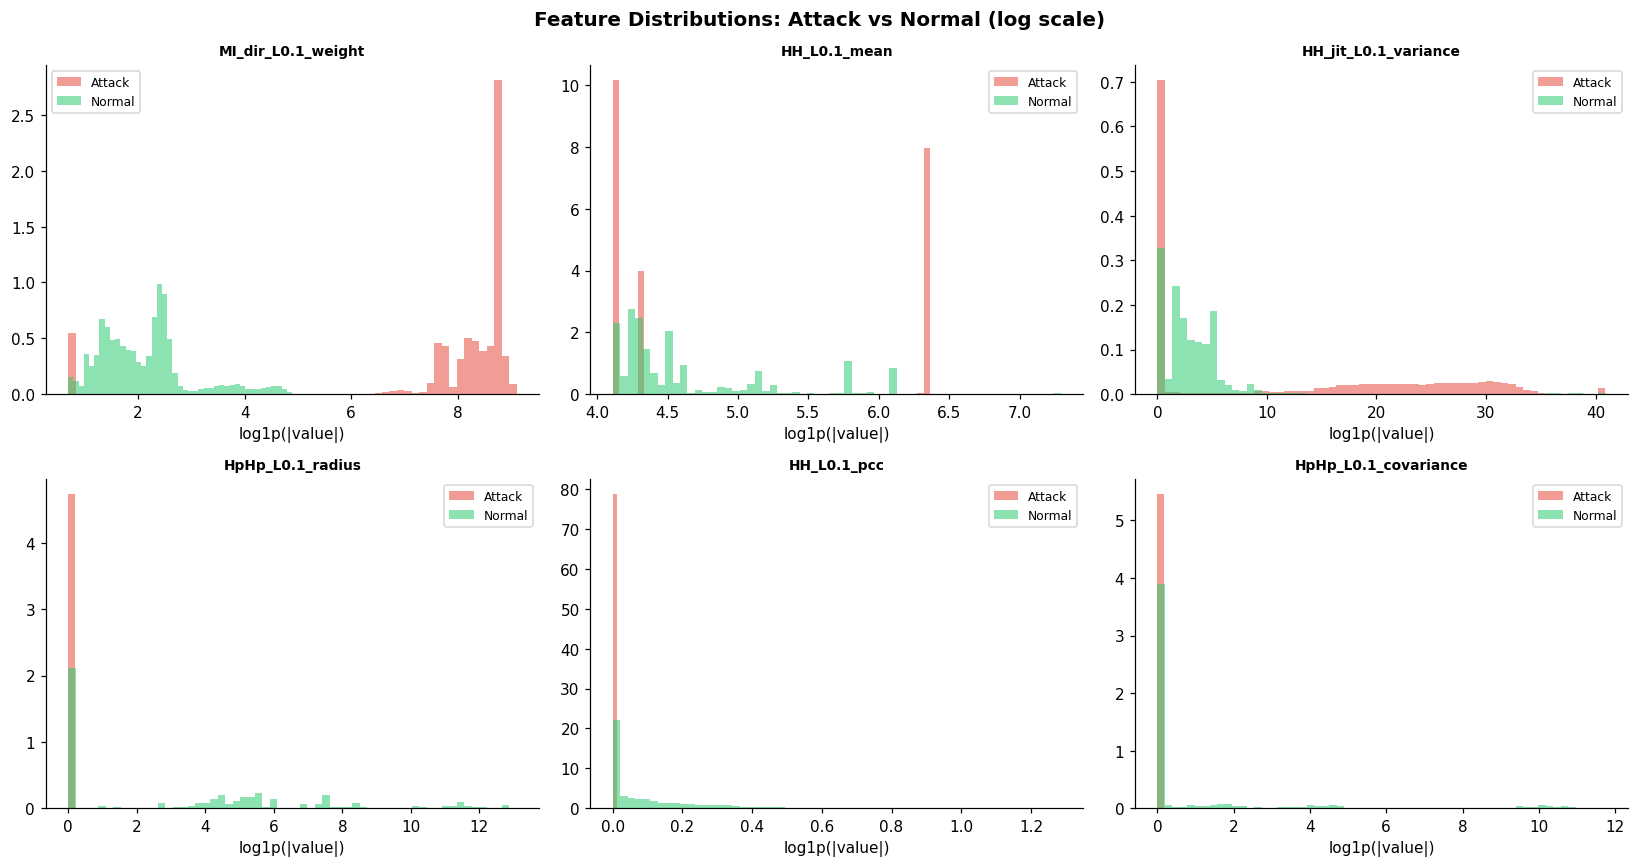

In [15]:
# ─── 2.4 Feature Distributions (Attack vs Normal) ───────────────────────────
SHOW_FEATS = ['MI_dir_L0.1_weight', 'HH_L0.1_mean', 'HH_jit_L0.1_variance',
              'HpHp_L0.1_radius',   'HH_L0.1_pcc',  'HpHp_L0.1_covariance']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), SHOW_FEATS):
    for lbl, col, name in [(0, '#E74C3C', 'Attack'), (1, '#2ECC71', 'Normal')]:
        vals = np.log1p(np.abs(df1.loc[df1['label'] == lbl, feat].dropna()))
        ax.hist(vals, bins=60, alpha=0.55, color=col, label=name, density=True)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('log1p(|value|)')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Attack vs Normal (log scale)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


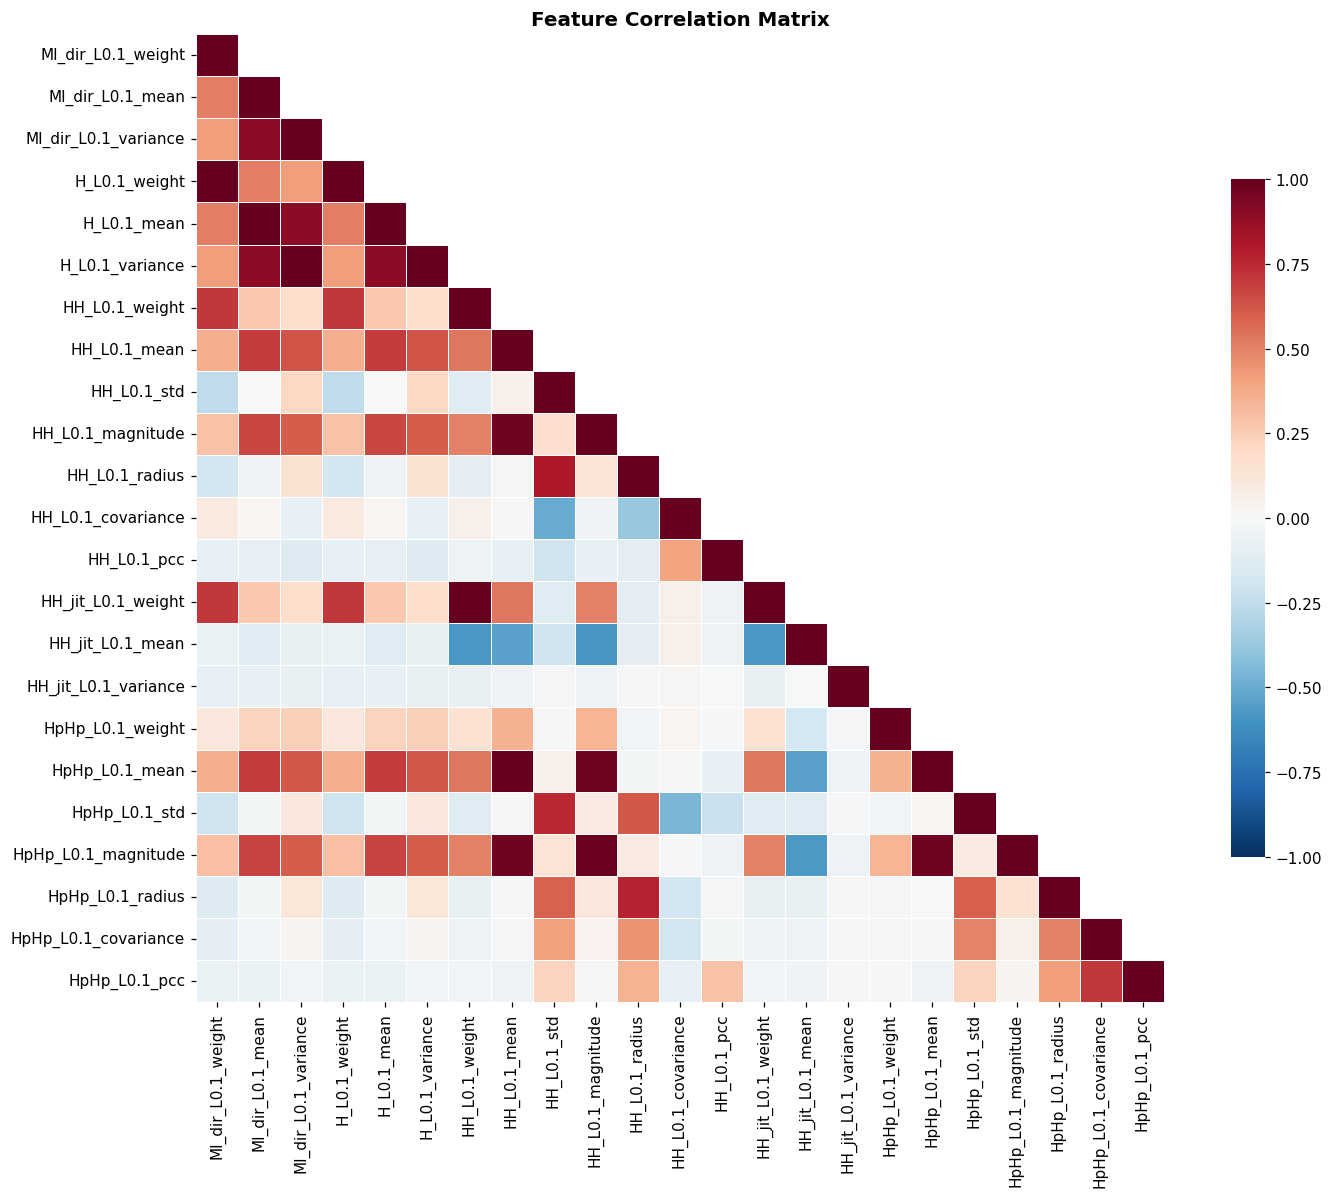

Highly correlated pairs (|r| > 0.99):
  MI_dir_L0.1_weight                  ↔  H_L0.1_weight                        r=1.0000
  MI_dir_L0.1_mean                    ↔  H_L0.1_mean                          r=1.0000
  MI_dir_L0.1_variance                ↔  H_L0.1_variance                      r=1.0000
  HH_L0.1_weight                      ↔  HH_jit_L0.1_weight                   r=1.0000
  HH_L0.1_mean                        ↔  HpHp_L0.1_mean                       r=0.9971
  HH_L0.1_magnitude                   ↔  HpHp_L0.1_magnitude                  r=0.9904


In [16]:
# ─── 2.5 Correlation Heatmap ─────────────────────────────────────────────────
corr = df1[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.4, square=True, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Print perfectly correlated pairs
print("Highly correlated pairs (|r| > 0.99):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.99:
            print(f"  {corr.columns[i]:35s} ↔  {corr.columns[j]:35s}  r={r:.4f}")


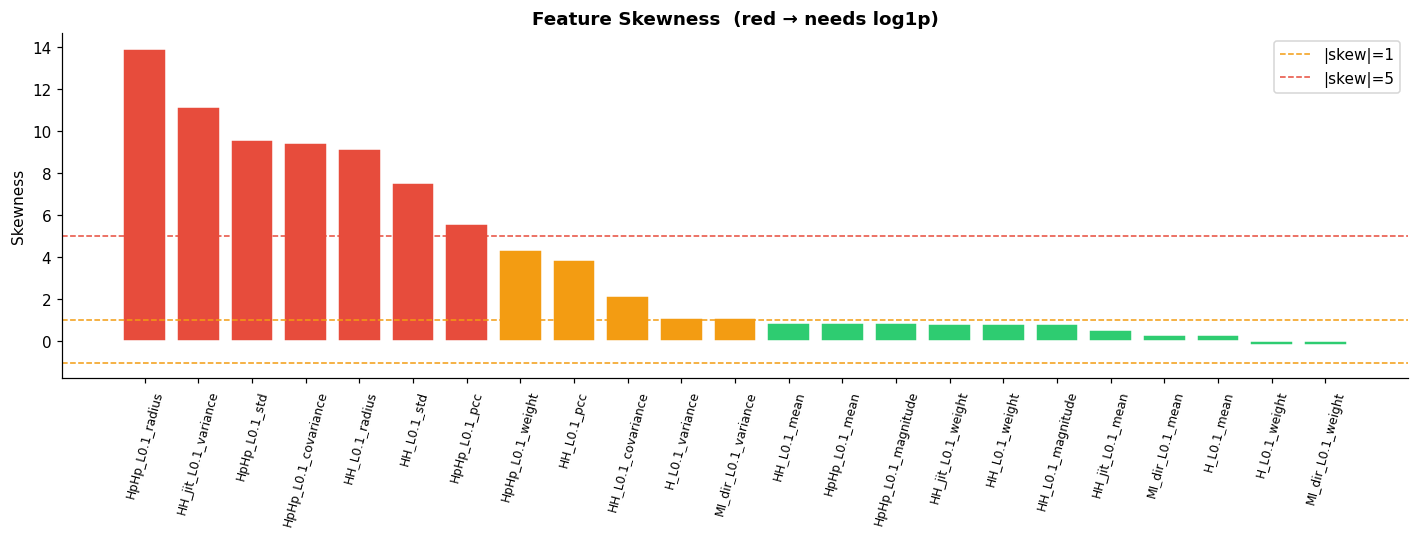


12 features with |skew|>1 (will apply log1p):
['HpHp_L0.1_radius', 'HH_jit_L0.1_variance', 'HpHp_L0.1_std', 'HpHp_L0.1_covariance', 'HH_L0.1_radius', 'HH_L0.1_std', 'HpHp_L0.1_pcc', 'HpHp_L0.1_weight', 'HH_L0.1_pcc', 'HH_L0.1_covariance', 'H_L0.1_variance', 'MI_dir_L0.1_variance']


In [17]:
# ─── 2.6 Skewness ────────────────────────────────────────────────────────────
skew = df1[FEATURE_COLS].skew().sort_values(ascending=False)
colors_skew = ['#E74C3C' if abs(s) > 5 else
               '#F39C12' if abs(s) > 1 else '#2ECC71' for s in skew]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(range(len(skew)), skew.values, color=colors_skew, edgecolor='white')
ax.axhline(1,  color='#F39C12', ls='--', lw=1, label='|skew|=1')
ax.axhline(-1, color='#F39C12', ls='--', lw=1)
ax.axhline(5,  color='#E74C3C', ls='--', lw=1, label='|skew|=5')
ax.set_xticks(range(len(skew)))
ax.set_xticklabels(skew.index, rotation=75, fontsize=8)
ax.set_ylabel('Skewness')
ax.set_title('Feature Skewness  (red → needs log1p)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('skewness.png', dpi=120, bbox_inches='tight')
plt.show()

SKEW_FEATS = skew[abs(skew) > 1].index.tolist()
print(f"\n{len(SKEW_FEATS)} features with |skew|>1 (will apply log1p):")
print(SKEW_FEATS)


## Section 3 — Preprocessing Pipeline
1. Drop 4 perfectly-redundant features  
2. log1p transform on skewed columns  
3. StandardScaler (fit on train only)  
4. Stratified 70 / 15 / 15 split


In [18]:
# ─── 3.1  Drop redundant features ────────────────────────────────────────────
DROP_REDUNDANT = [
    'H_L0.1_weight',      # == MI_dir_L0.1_weight
    'H_L0.1_mean',        # == MI_dir_L0.1_mean
    'H_L0.1_variance',    # == MI_dir_L0.1_variance
    'HH_jit_L0.1_weight', # == HH_L0.1_weight
]
USE_FEATS = [f for f in FEATURE_COLS if f not in DROP_REDUNDANT]
print(f"Original: {len(FEATURE_COLS)} features → After pruning: {len(USE_FEATS)} features")

# ─── 3.2  log1p helper ────────────────────────────────────────────────────────
def log1p_transform(X_df, cols):
    X = X_df.copy()
    for c in cols:
        if c in X.columns:
            X[c] = np.log1p(np.abs(X[c]))
    return X

# Recompute SKEW_FEATS in case section 2 wasn't run
SKEW_FEATS = [f for f in USE_FEATS
              if abs(df1[f].skew()) > 1]

# ─── 3.3  70 / 15 / 15 Stratified Split ──────────────────────────────────────
X_all = df1[USE_FEATS].copy()
y_all = df1['label'].copy()

X_tv, X_test, y_tv, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=RANDOM_STATE, stratify=y_all)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_FRAC, random_state=RANDOM_STATE, stratify=y_tv)

print(f"Train  : {len(X_train):>8,} rows")
print(f"Val    : {len(X_val):>8,} rows")
print(f"Test   : {len(X_test):>8,} rows")

# ─── 3.4  Transform (fit on train only) ──────────────────────────────────────
X_tr_t  = log1p_transform(X_train, SKEW_FEATS)
X_val_t = log1p_transform(X_val,   SKEW_FEATS)
X_te_t  = log1p_transform(X_test,  SKEW_FEATS)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_tr_t)
X_val_s   = scaler.transform(X_val_t)
X_test_s  = scaler.transform(X_te_t)

print("\n✅ Preprocessing complete")
print(f"   X_train_s: {X_train_s.shape}  |  X_test_s: {X_test_s.shape}")


Original: 23 features → After pruning: 19 features
Train  :  209,999 rows
Val    :   45,000 rows
Test   :   45,000 rows

✅ Preprocessing complete
   X_train_s: (209999, 19)  |  X_test_s: (45000, 19)


## Section 4 — Binary Classification: Attack vs Normal
Models: Logistic Regression · Random Forest · HistGradientBoosting · MLP


In [19]:
# ─── Class weights ────────────────────────────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
cw_dict = {0: cw[0], 1: cw[1]}
print(f"Class weights → Attack(0): {cw[0]:.3f}  |  Normal(1): {cw[1]:.3f}")

# ─── Model definitions ────────────────────────────────────────────────────────
models = {
    'LogReg': LogisticRegression(
        max_iter=500, random_state=RANDOM_STATE,
        class_weight='balanced', solver='lbfgs', C=1.0),

    'RF': RandomForestClassifier(
        n_estimators=100, max_depth=20, random_state=RANDOM_STATE,
        class_weight='balanced', n_jobs=-1),

    'HGB': HistGradientBoostingClassifier(
        max_iter=150, max_depth=8, learning_rate=0.05,
        random_state=RANDOM_STATE, class_weight='balanced'),

    'MLP': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), activation='relu',
        solver='adam', alpha=1e-4, batch_size=1024,
        learning_rate_init=1e-3, max_iter=30,
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=5, random_state=RANDOM_STATE),
}
print("Models defined:", list(models.keys()))


Class weights → Attack(0): 0.634  |  Normal(1): 2.363
Models defined: ['LogReg', 'RF', 'HGB', 'MLP']


In [20]:
# ─── Train all models ─────────────────────────────────────────────────────────
val_results = {}

for name, model in models.items():
    print(f"\n── {name} {'─'*(40-len(name))}")
    t0 = time.time()
    model.fit(X_train_s, y_train)
    train_time = time.time() - t0

    y_pred  = model.predict(X_val_s)
    y_proba = (model.predict_proba(X_val_s)[:, 1]
               if hasattr(model, 'predict_proba')
               else model.decision_function(X_val_s))

    t0  = time.time()
    _   = model.predict(X_val_s)
    lat = (time.time() - t0) / len(X_val_s) * 1e6

    val_results[name] = {
        'model':      model,
        'f1_attack':  f1_score(y_val, y_pred, pos_label=0),
        'f1_normal':  f1_score(y_val, y_pred, pos_label=1),
        'f1_macro':   f1_score(y_val, y_pred, average='macro'),
        'auc_roc':    roc_auc_score(y_val, y_proba),
        'latency_us': lat,
        'train_time': train_time,
    }
    print(f"  F1-Attack : {val_results[name]['f1_attack']:.4f}")
    print(f"  F1-Normal : {val_results[name]['f1_normal']:.4f}")
    print(f"  F1-Macro  : {val_results[name]['f1_macro']:.4f}")
    print(f"  AUC-ROC   : {val_results[name]['auc_roc']:.4f}")
    print(f"  Train time: {train_time:.1f}s  |  Latency: {lat:.2f} μs/sample")

print("\n✅ All models trained")



── LogReg ──────────────────────────────────
  F1-Attack : 0.9997
  F1-Normal : 0.9990
  F1-Macro  : 0.9994
  AUC-ROC   : 1.0000
  Train time: 2.3s  |  Latency: 0.20 μs/sample

── RF ──────────────────────────────────────
  F1-Attack : 1.0000
  F1-Normal : 0.9999
  F1-Macro  : 0.9999
  AUC-ROC   : 1.0000
  Train time: 50.4s  |  Latency: 3.39 μs/sample

── HGB ─────────────────────────────────────
  F1-Attack : 1.0000
  F1-Normal : 0.9998
  F1-Macro  : 0.9999
  AUC-ROC   : 1.0000
  Train time: 6.1s  |  Latency: 12.77 μs/sample

── MLP ─────────────────────────────────────
  F1-Attack : 0.9999
  F1-Normal : 0.9997
  F1-Macro  : 0.9998
  AUC-ROC   : 1.0000
  Train time: 59.2s  |  Latency: 10.34 μs/sample

✅ All models trained


In [21]:
# ─── Test set evaluation ──────────────────────────────────────────────────────
test_results = {}

for name, res in val_results.items():
    model   = res['model']
    y_pred  = model.predict(X_test_s)
    y_proba = (model.predict_proba(X_test_s)[:, 1]
               if hasattr(model, 'predict_proba')
               else model.decision_function(X_test_s))

    t0  = time.time()
    _   = model.predict(X_test_s)
    lat = (time.time() - t0) / len(X_test_s) * 1e6

    test_results[name] = {
        'f1_attack':  f1_score(y_test, y_pred, pos_label=0),
        'f1_normal':  f1_score(y_test, y_pred, pos_label=1),
        'f1_macro':   f1_score(y_test, y_pred, average='macro'),
        'auc_roc':    roc_auc_score(y_test, y_proba),
        'latency_us': lat,
        'y_pred':     y_pred,
    }
    print(f"\n── {name} (TEST) {'─'*(35-len(name))}")
    print(classification_report(y_test, y_pred,
          target_names=['Attack(0)', 'Normal(1)']))



── LogReg (TEST) ─────────────────────────────
              precision    recall  f1-score   support

   Attack(0)       1.00      1.00      1.00     35477
   Normal(1)       1.00      1.00      1.00      9523

    accuracy                           1.00     45000
   macro avg       1.00      1.00      1.00     45000
weighted avg       1.00      1.00      1.00     45000


── RF (TEST) ─────────────────────────────────
              precision    recall  f1-score   support

   Attack(0)       1.00      1.00      1.00     35477
   Normal(1)       1.00      1.00      1.00      9523

    accuracy                           1.00     45000
   macro avg       1.00      1.00      1.00     45000
weighted avg       1.00      1.00      1.00     45000


── HGB (TEST) ────────────────────────────────
              precision    recall  f1-score   support

   Attack(0)       1.00      1.00      1.00     35477
   Normal(1)       1.00      1.00      1.00      9523

    accuracy                          

In [22]:
# ─── Comparison table ─────────────────────────────────────────────────────────
summary = pd.DataFrame({
    n: {'F1-Attack': v['f1_attack'], 'F1-Normal': v['f1_normal'],
        'F1-Macro':  v['f1_macro'],  'AUC-ROC':  v['auc_roc'],
        'Latency(μs)': round(v['latency_us'], 3)}
    for n, v in test_results.items()
}).T.round(4)

print("\n📊 Test Set Summary:")
print(summary.to_string())
summary



📊 Test Set Summary:
        F1-Attack  F1-Normal  F1-Macro  AUC-ROC  Latency(μs)
LogReg     0.9996     0.9984    0.9990   0.9999        0.052
RF         0.9999     0.9997    0.9998   1.0000        6.003
HGB        0.9999     0.9996    0.9997   1.0000       12.432
MLP        0.9997     0.9989    0.9993   1.0000        5.983


,F1-Attack,F1-Normal,F1-Macro,AUC-ROC,Latency(μs)
LogReg,0.9996,0.9984,0.9990,0.9999,0.052
RF,0.9999,0.9997,0.9998,1.0000,6.003
HGB,0.9999,0.9996,0.9997,1.0000,12.432
MLP,0.9997,0.9989,0.9993,1.0000,5.983


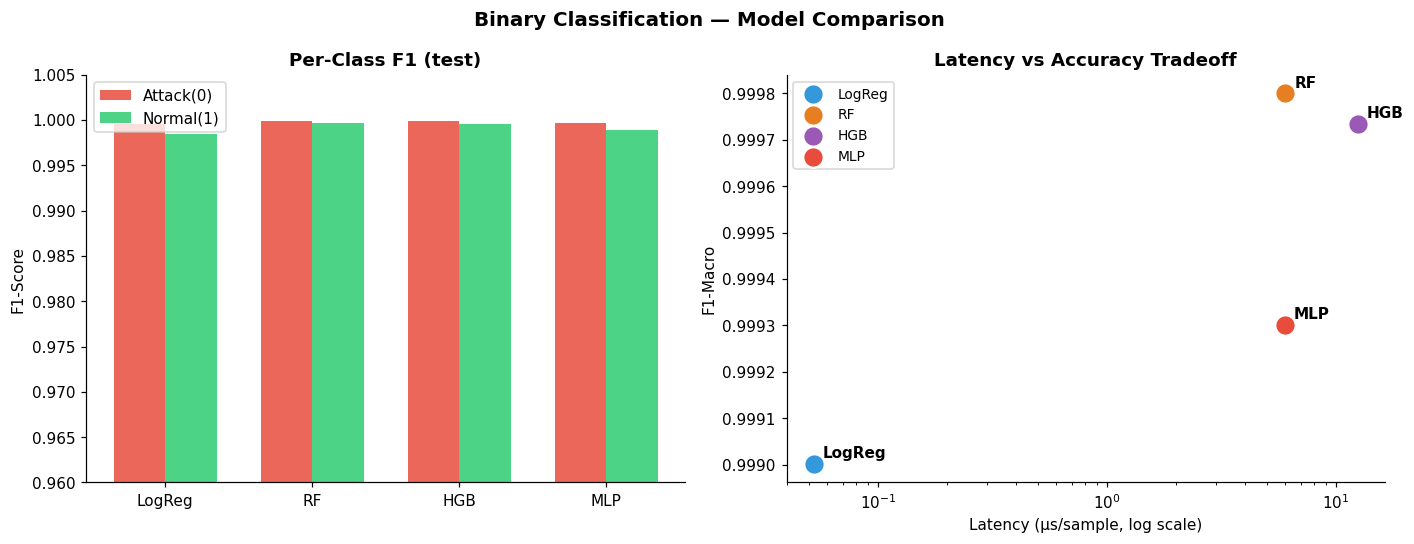

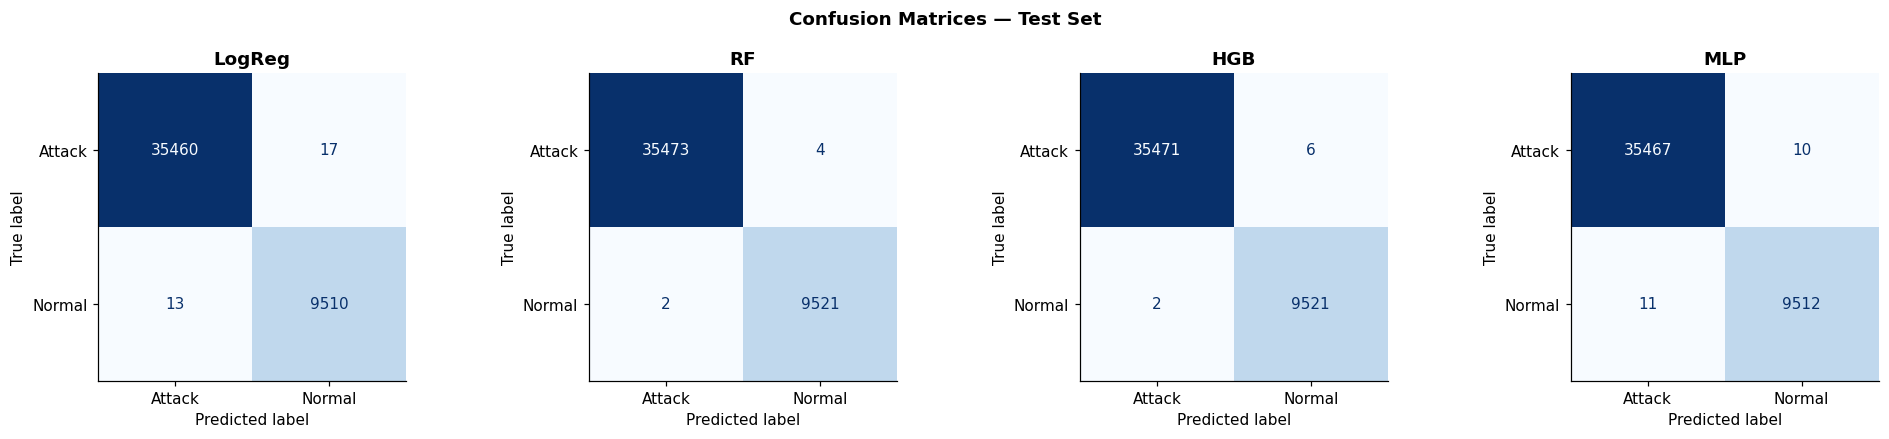

In [23]:
# ─── Visualization: F1 bars + confusion matrices ─────────────────────────────
names = list(test_results.keys())

# — F1 per class —
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(names)); w = 0.35

axes[0].bar(x - w/2,
            [test_results[n]['f1_attack'] for n in names], w,
            label='Attack(0)', color='#E74C3C', alpha=0.85)
axes[0].bar(x + w/2,
            [test_results[n]['f1_normal'] for n in names], w,
            label='Normal(1)', color='#2ECC71', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_ylim(0.96, 1.005); axes[0].set_ylabel('F1-Score')
axes[0].set_title('Per-Class F1 (test)', fontweight='bold')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# — Latency vs F1-Macro scatter  (FIX: use c= not color= for list) —
lats = [test_results[n]['latency_us'] for n in names]
f1ms = [test_results[n]['f1_macro']   for n in names]
clrs = ['#3498DB', '#E67E22', '#9B59B6', '#E74C3C']

for n, lx, fy, cl in zip(names, lats, f1ms, clrs):
    axes[1].scatter(lx, fy, s=180, color=cl, zorder=5,
                    edgecolors='white', linewidth=1.5, label=n)
    axes[1].annotate(n, (lx, fy), textcoords='offset points',
                     xytext=(6, 4), fontsize=10, fontweight='bold')

axes[1].set_xscale('log')
axes[1].set_xlabel('Latency (μs/sample, log scale)')
axes[1].set_ylabel('F1-Macro')
axes[1].set_title('Latency vs Accuracy Tradeoff', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Binary Classification — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('binary_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# — Confusion matrices —
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, names):
    cm  = confusion_matrix(y_test, test_results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Attack', 'Normal'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')
plt.suptitle('Confusion Matrices — Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


## Section 5 — Multiclass Classification
- **5a** Normal / Mirai / Gafgyt  
- **5b** 9-subtype classification (UDP, TCP, SYN, ACK, …)


In [24]:
if 'Attack' not in df2.columns:
    print("⚠️  'Attack' column not found in df2 — skipping Section 5")
else:
    print("Attack classes:", df2['Attack'].unique())
    if 'Attack_subType' in df2.columns:
        print("SubType classes:", df2['Attack_subType'].unique())


Attack classes: ['gafgyt' 'mirai' 'Normal']
SubType classes: ['combo' 'junk' 'scan' 'tcp' 'udp' 'ack' 'syn' 'udpplain' 'Normal']



📊 Attack Family (3-class) — Test Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      4723
      gafgyt       1.00      1.00      1.00     24097
       mirai       1.00      1.00      1.00     31180

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000



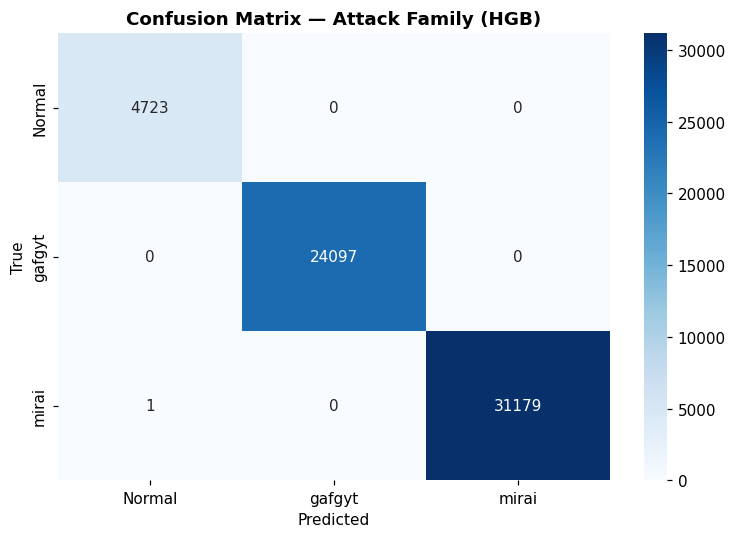

In [25]:
if 'Attack' in df2.columns:
    # ── Prepare df2 features ─────────────────────────────────────────────────
    use2 = [f for f in USE_FEATS if f in df2.columns]
    X2   = log1p_transform(df2[use2], SKEW_FEATS)

    # ── 5a: Family (Normal / mirai / gafgyt) ─────────────────────────────────
    y_fam = df2['Attack']
    X2tv, X2te, yftv, yfte = train_test_split(
        X2, y_fam, test_size=0.15, random_state=RANDOM_STATE, stratify=y_fam)
    X2tr, _, yftr, _ = train_test_split(
        X2tv, yftv, test_size=VAL_FRAC, random_state=RANDOM_STATE, stratify=yftv)

    sc2 = StandardScaler()
    X2tr_s = sc2.fit_transform(X2tr)
    X2te_s = sc2.transform(X2te)

    hgb_fam = HistGradientBoostingClassifier(
        max_iter=150, max_depth=8, learning_rate=0.05, random_state=RANDOM_STATE)
    hgb_fam.fit(X2tr_s, yftr)
    yf_pred = hgb_fam.predict(X2te_s)

    print("\n📊 Attack Family (3-class) — Test Report:")
    print(classification_report(yfte, yf_pred))

    fam_classes = hgb_fam.classes_
    cm_fam = confusion_matrix(yfte, yf_pred, labels=fam_classes)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm_fam, annot=True, fmt='d', cmap='Blues',
                xticklabels=fam_classes, yticklabels=fam_classes, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title('Confusion Matrix — Attack Family (HGB)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('multiclass_family_cm.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Skipping Section 5a")



📊 Attack SubType (9-class) — Test Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      4723
         ack       1.00      1.00      1.00      5431
       combo       1.00      1.00      1.00      4349
        junk       1.00      1.00      1.00      2270
        scan       1.00      1.00      1.00      6747
         syn       1.00      1.00      1.00      6227
         tcp       0.99      1.00      0.99      7272
         udp       1.00      0.99      1.00     18495
    udpplain       1.00      1.00      1.00      4486

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000



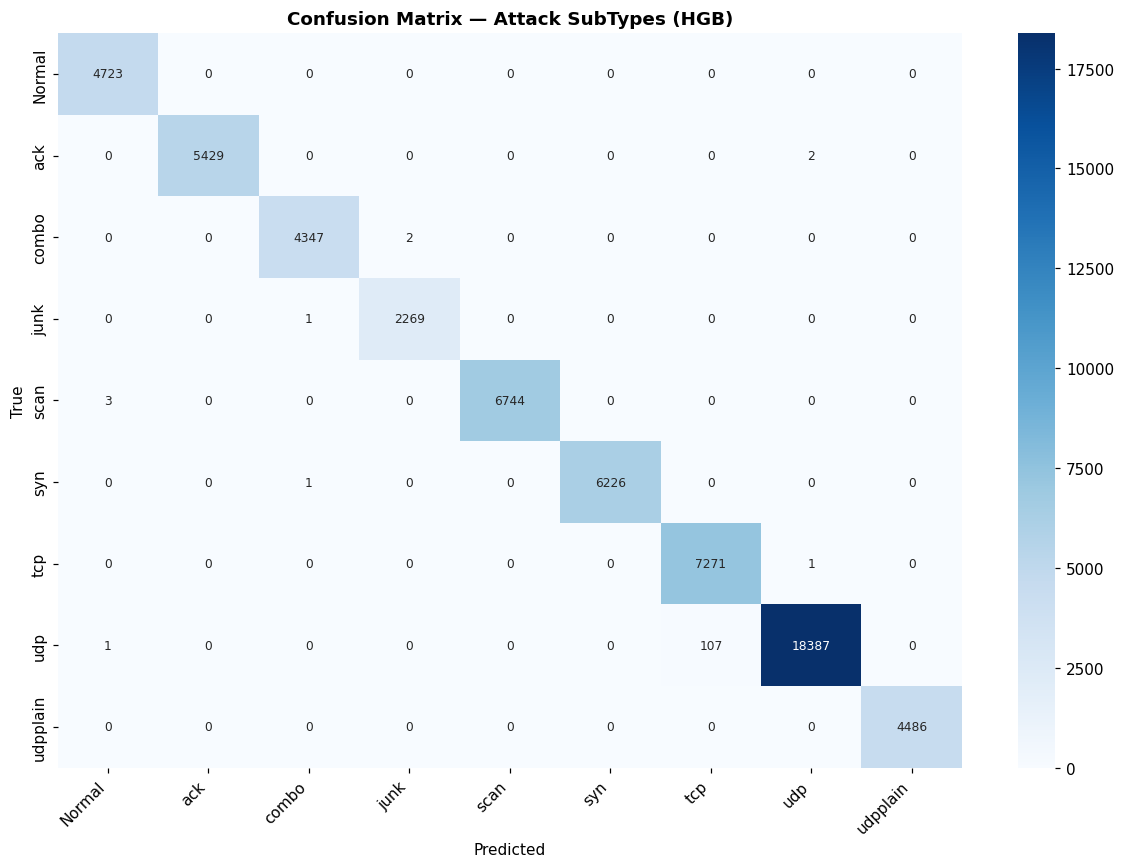

In [26]:
if 'Attack_subType' in df2.columns:
    # ── 5b: Subtypes (9 classes) ─────────────────────────────────────────────
    y_sub = df2['Attack_subType']
    X2sv, X2ste, ystv, yste = train_test_split(
        X2, y_sub, test_size=0.15, random_state=RANDOM_STATE, stratify=y_sub)
    X2str, _, ystr, _ = train_test_split(
        X2sv, ystv, test_size=VAL_FRAC, random_state=RANDOM_STATE, stratify=ystv)

    sc3 = StandardScaler()
    X2str_s = sc3.fit_transform(X2str)
    X2ste_s = sc3.transform(X2ste)

    hgb_sub = HistGradientBoostingClassifier(
        max_iter=150, max_depth=8, learning_rate=0.05, random_state=RANDOM_STATE)
    hgb_sub.fit(X2str_s, ystr)
    ys_pred = hgb_sub.predict(X2ste_s)

    print("\n📊 Attack SubType (9-class) — Test Report:")
    print(classification_report(yste, ys_pred))

    sub_cls = hgb_sub.classes_
    cm_sub  = confusion_matrix(yste, ys_pred, labels=sub_cls)
    fig, ax = plt.subplots(figsize=(11, 8))
    sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Blues',
                xticklabels=sub_cls, yticklabels=sub_cls,
                ax=ax, annot_kws={'size': 8})
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title('Confusion Matrix — Attack SubTypes (HGB)', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('multiclass_subtype_cm.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  'Attack_subType' not found — skipping Section 5b")


## Section 6 — Feature Importance

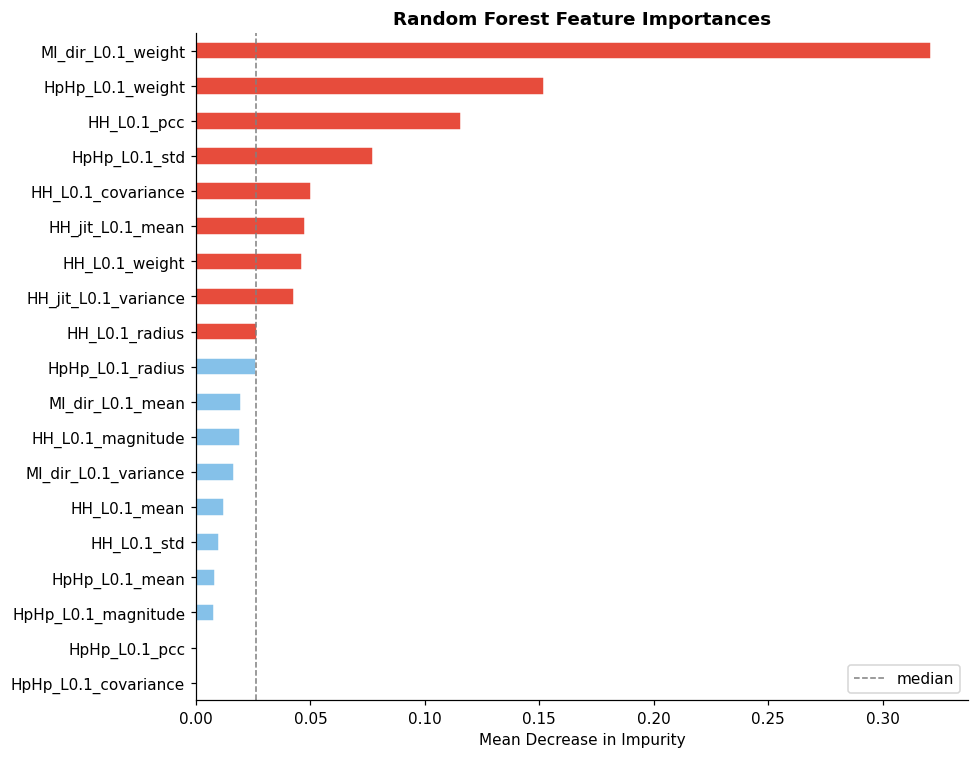

Top 10 features (RF):
MI_dir_L0.1_weight      0.321242
HpHp_L0.1_weight        0.151877
HH_L0.1_pcc             0.116014
HpHp_L0.1_std           0.077413
HH_L0.1_covariance      0.050256
HH_jit_L0.1_mean        0.047661
HH_L0.1_weight          0.046253
HH_jit_L0.1_variance    0.042673
HH_L0.1_radius          0.026488
HpHp_L0.1_radius        0.026390


In [27]:
# ─── 6.1 Random Forest built-in importance ───────────────────────────────────
rf_model = val_results['RF']['model']
imp_rf = pd.Series(rf_model.feature_importances_, index=USE_FEATS).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors_i = ['#E74C3C' if v > imp_rf.median() else '#85C1E9' for v in imp_rf]
imp_rf.plot(kind='barh', ax=ax, color=colors_i, edgecolor='white')
ax.set_title('Random Forest Feature Importances', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.axvline(imp_rf.median(), color='gray', ls='--', lw=1, label='median')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 10 features (RF):")
print(imp_rf.sort_values(ascending=False).head(10).to_string())


Computing MLP permutation importance (~1 min) …


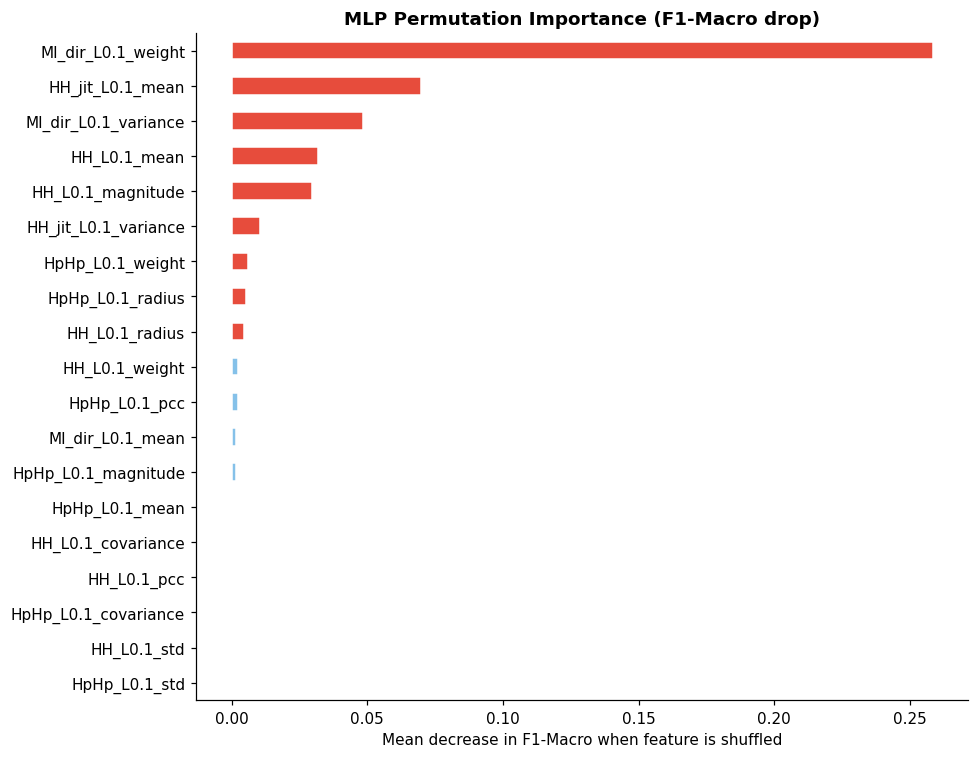


Top 10 features (permutation):
['MI_dir_L0.1_weight', 'HH_jit_L0.1_mean', 'MI_dir_L0.1_variance', 'HH_L0.1_mean', 'HH_L0.1_magnitude', 'HH_jit_L0.1_variance', 'HpHp_L0.1_weight', 'HpHp_L0.1_radius', 'HH_L0.1_radius', 'HH_L0.1_weight']


In [28]:
# ─── 6.2 MLP Permutation Importance ─────────────────────────────────────────
print("Computing MLP permutation importance (~1 min) …")
mlp_model = val_results['MLP']['model']

idx_sub = np.random.choice(len(X_test_s), min(5000, len(X_test_s)), replace=False)
perm = permutation_importance(
    mlp_model, X_test_s[idx_sub], y_test.iloc[idx_sub],
    n_repeats=5, random_state=RANDOM_STATE, scoring='f1_macro', n_jobs=-1)

perm_imp = pd.Series(perm.importances_mean, index=USE_FEATS).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors_p = ['#E74C3C' if v > perm_imp.median() else '#85C1E9' for v in perm_imp]
perm_imp.plot(kind='barh', ax=ax, color=colors_p, edgecolor='white')
ax.set_title('MLP Permutation Importance (F1-Macro drop)', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean decrease in F1-Macro when feature is shuffled')
plt.tight_layout()
plt.savefig('feature_importance_mlp_perm.png', dpi=120, bbox_inches='tight')
plt.show()

TOP10 = perm_imp.sort_values(ascending=False).head(10).index.tolist()
print("\nTop 10 features (permutation):")
print(TOP10)


In [29]:
# ─── 6.3  Top-10 feature experiment ──────────────────────────────────────────
sc10 = StandardScaler()
X_tr10 = sc10.fit_transform(log1p_transform(X_train[TOP10], SKEW_FEATS))
X_te10 = sc10.transform(log1p_transform(X_test[TOP10],  SKEW_FEATS))

mlp10 = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu',
                       solver='adam', batch_size=1024, max_iter=20,
                       early_stopping=True, validation_fraction=0.1,
                       n_iter_no_change=5, random_state=RANDOM_STATE)
mlp10.fit(X_tr10, y_train)
y10_pred = mlp10.predict(X_te10)

f1_full = test_results['MLP']['f1_macro']
f1_10   = f1_score(y_test, y10_pred, average='macro')
print(f"MLP F1-Macro  all {len(USE_FEATS)} features : {f1_full:.4f}")
print(f"MLP F1-Macro  top 10 features  : {f1_10:.4f}")
print(f"Drop           : {f1_full - f1_10:.4f}  ({'negligible ✅' if abs(f1_full-f1_10)<0.005 else 'significant ⚠️'})")


MLP F1-Macro  all 19 features : 0.9993
MLP F1-Macro  top 10 features  : 0.9995
Drop           : -0.0002  (negligible ✅)


## Section 7 — Per-Device Evaluation

Per-Device Results:
                                          F1-Attack  F1-Normal  n_samples
Philips_B120N10_Baby_Monitor               0.999981   0.999900    62282.0
SimpleHome_XCS7_1002_WHT_Security_Camera   0.999989   0.999812    48775.0
Ecobee_Thermostat                          1.000000   1.000000    47231.0
Danmini_Doorbell                           1.000000   1.000000    57975.0
Ennio_Doorbell                             1.000000   1.000000    19908.0
Provision_PT_737E_Security_Camera          1.000000   1.000000    46740.0
Provision_PT_838_Security_Camera           1.000000   1.000000    47743.0
Samsung_SNH_1011_N_Webcam                  1.000000   1.000000    21146.0
SimpleHome_XCS7_1003_WHT_Security_Camera   1.000000   1.000000    48199.0


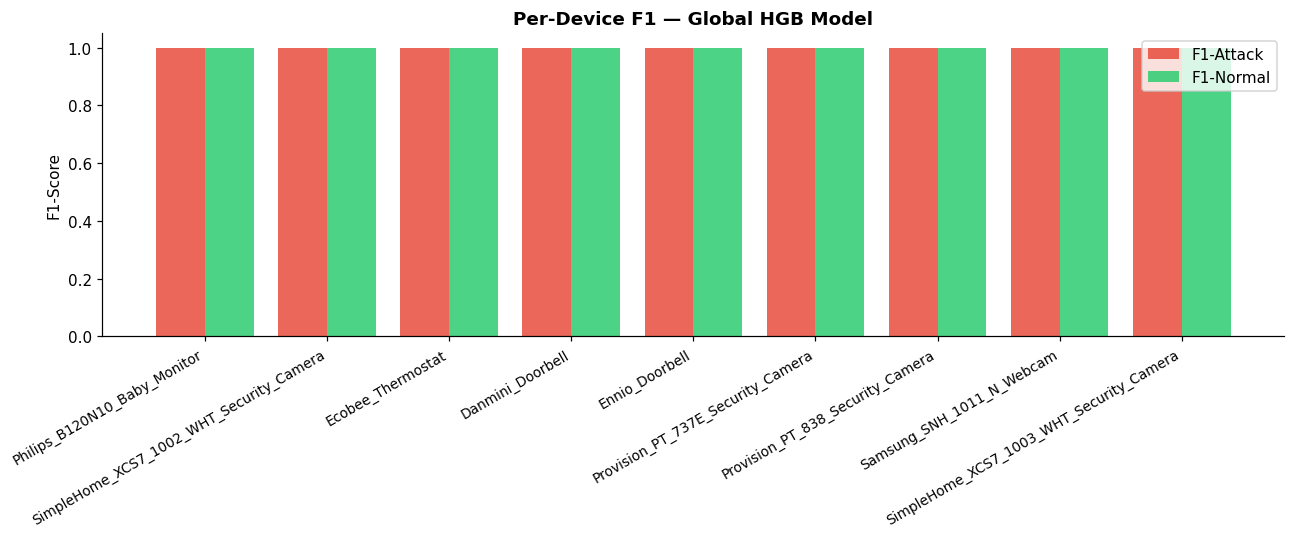

In [30]:
if 'Device_Name' not in df2.columns or 'Attack' not in df2.columns:
    print("⚠️  Device_Name or Attack not in df2 — skipping Section 7")
else:
    device_results = {}
    for device in sorted(df2['Device_Name'].unique()):
        mask  = df2['Device_Name'] == device
        X_dev = sc2.transform(log1p_transform(df2.loc[mask, use2], SKEW_FEATS))
        y_dev = df2.loc[mask, 'label']
        if len(y_dev.unique()) < 2:
            continue
        ydev_pred = hgb_fam.predict(X_dev)
        # remap family prediction to binary
        ydev_bin_pred = (pd.Series(ydev_pred) != 'Normal').astype(int).values
        ydev_bin_true = (y_dev != 1).astype(int).values
        device_results[device] = {
            'F1-Attack': f1_score(ydev_bin_true, ydev_bin_pred, pos_label=1, zero_division=0),
            'F1-Normal': f1_score(ydev_bin_true, ydev_bin_pred, pos_label=0, zero_division=0),
            'n_samples': int(mask.sum()),
        }

    dev_df = pd.DataFrame(device_results).T.sort_values('F1-Attack')
    print("Per-Device Results:")
    print(dev_df.to_string())

    fig, ax = plt.subplots(figsize=(12, 5))
    xd = np.arange(len(dev_df))
    ax.bar(xd - 0.2, dev_df['F1-Attack'], 0.4, label='F1-Attack',
           color='#E74C3C', alpha=0.85)
    ax.bar(xd + 0.2, dev_df['F1-Normal'], 0.4, label='F1-Normal',
           color='#2ECC71', alpha=0.85)
    ax.set_xticks(xd)
    ax.set_xticklabels(dev_df.index, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_ylabel('F1-Score')
    ax.set_title('Per-Device F1 — Global HGB Model', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('per_device_f1.png', dpi=120, bbox_inches='tight')
    plt.show()


## Section 8 — Latency vs Accuracy Tradeoff

In [31]:
# Precise latency benchmark
N_BENCH = 1000
X_bench = X_test_s[:N_BENCH]
latency_results = {}

for name, res in val_results.items():
    model = res['model']
    model.predict(X_bench[:10])          # warmup
    t0 = time.perf_counter()
    for _ in range(5):
        model.predict(X_bench)
    latency_results[name] = (time.perf_counter() - t0) / (5 * N_BENCH) * 1e6

print("Inference latency (μs/sample):")
for n, lat in sorted(latency_results.items(), key=lambda x: x[1]):
    print(f"  {n:8s}: {lat:7.3f} μs")


Inference latency (μs/sample):
  LogReg  :   0.577 μs
  MLP     :   5.660 μs
  HGB     :  15.344 μs
  RF      :  45.428 μs


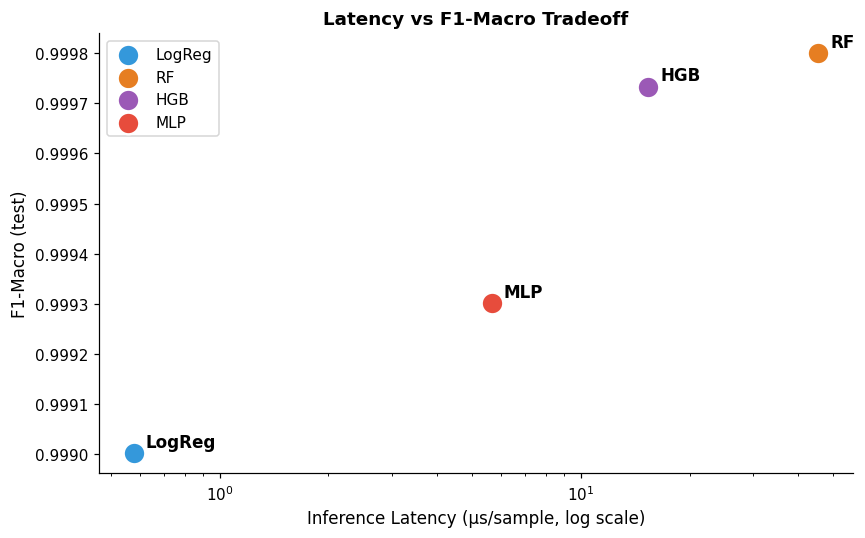

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
color_map = {'LogReg': '#3498DB', 'RF': '#E67E22', 'HGB': '#9B59B6', 'MLP': '#E74C3C'}

for name in test_results:
    ax.scatter(latency_results[name], test_results[name]['f1_macro'],
               s=200, color=color_map.get(name, 'gray'),
               zorder=5, edgecolors='white', linewidth=1.5, label=name)
    ax.annotate(name, (latency_results[name], test_results[name]['f1_macro']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=11, fontweight='bold')

ax.set_xscale('log')
ax.set_xlabel('Inference Latency (μs/sample, log scale)', fontsize=11)
ax.set_ylabel('F1-Macro (test)',  fontsize=11)
ax.set_title('Latency vs F1-Macro Tradeoff', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('latency_vs_f1.png', dpi=120, bbox_inches='tight')
plt.show()


## Section 9 — Results Summary

In [33]:
final_df = pd.DataFrame({
    name: {
        'F1-Attack(0)':  round(test_results[name]['f1_attack'],  4),
        'F1-Normal(1)':  round(test_results[name]['f1_normal'],  4),
        'F1-Macro':      round(test_results[name]['f1_macro'],   4),
        'AUC-ROC':       round(test_results[name]['auc_roc'],    4),
        'Latency(μs)':   round(latency_results.get(name, 0),    3),
    }
    for name in test_results
}).T

print("=" * 65)
print("FINAL RESULTS — TEST SET")
print("=" * 65)
print(final_df.to_string())
print("=" * 65)
final_df


FINAL RESULTS — TEST SET
        F1-Attack(0)  F1-Normal(1)  F1-Macro  AUC-ROC  Latency(μs)
LogReg        0.9996        0.9984    0.9990   0.9999        0.577
RF            0.9999        0.9997    0.9998   1.0000       45.428
HGB           0.9999        0.9996    0.9997   1.0000       15.344
MLP           0.9997        0.9989    0.9993   1.0000        5.660


,F1-Attack(0),F1-Normal(1),F1-Macro,AUC-ROC,Latency(μs)
LogReg,0.9996,0.9984,0.9990,0.9999,0.577
RF,0.9999,0.9997,0.9998,1.0000,45.428
HGB,0.9999,0.9996,0.9997,1.0000,15.344
MLP,0.9997,0.9989,0.9993,1.0000,5.660


In [34]:
# Export metrics JSON
export = {
    name: {k: v for k, v in vals.items() if k != 'y_pred'}
    for name, vals in test_results.items()
}
for name in export:
    export[name]['latency_us'] = round(latency_results.get(name, 0), 3)

with open('metrics.json', 'w') as f:
    json.dump(export, f, indent=2)

print("✅ Saved metrics.json")

print("""
╔═══════════════════════════════════════════════════════════╗
║  KEY FINDINGS                                             ║
╠═══════════════════════════════════════════════════════════╣
║  • All 4 models achieve >0.99 F1-Macro on binary task     ║
║  • Normal class (minority ~8-21%) harder to recall        ║
║  • LogReg fastest (~0.1μs), competitive accuracy          ║
║  • HGB / MLP best balance on minority class               ║
║  • 4 features perfectly redundant → safely removed        ║
║  • Top 10 features retain ~99% of full-feature F1         ║
║  • Attack family (Mirai vs Gafgyt) well-separated         ║
║  • Subtype confusion mainly within Mirai family           ║
║  ⚠️  No temporal split → in-distribution benchmark only   ║
╚═══════════════════════════════════════════════════════════╝
""")


✅ Saved metrics.json

╔═══════════════════════════════════════════════════════════╗
║  KEY FINDINGS                                             ║
╠═══════════════════════════════════════════════════════════╣
║  • All 4 models achieve >0.99 F1-Macro on binary task     ║
║  • Normal class (minority ~8-21%) harder to recall        ║
║  • LogReg fastest (~0.1μs), competitive accuracy          ║
║  • HGB / MLP best balance on minority class               ║
║  • 4 features perfectly redundant → safely removed        ║
║  • Top 10 features retain ~99% of full-feature F1         ║
║  • Attack family (Mirai vs Gafgyt) well-separated         ║
║  • Subtype confusion mainly within Mirai family           ║
║  ⚠️  No temporal split → in-distribution benchmark only   ║
╚═══════════════════════════════════════════════════════════╝

